In [62]:
#primero,se instalan librerias para descargar y ver los datos:

import yfinance as yf
import pandas as pd
T = ["BCH", "CLP=X"]
df = yf.download(T, start = "2025-01-01", end = "2026-01-01") #esto descarga el valor del dolar en chile y el de la accion del banco de chile en el intervalo elegido

#Hipotesis tentativa: El valor de la accion del banco de chile tiende a bajar cuando hay cambios bruscos en el precio del dolar, debido a la incertidumbre

df.head()


#df_loc = df.loc["2025-01-01": "2026-03-01"]



/tmp/ipykernel_10083/2835713070.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(T, start = "2025-01-01", end = "2026-01-01") #esto descarga el valor del dolar en chile y el de la accion del banco de chile en el intervalo elegido
[*********************100%***********************]  2 of 2 completed


Price           Close                    High                     Low  \
Ticker            BCH        CLP=X        BCH        CLP=X        BCH   
Date                                                                    
2025-01-02  20.781691   993.349976  21.188450  1006.520020  20.680002   
2025-01-03  20.476622  1004.130005  20.680002  1011.219971  20.393421   
2025-01-06  20.735468  1010.380005  20.938847  1010.299988  20.559821   
2025-01-07  20.994314  1010.580017  21.169961  1010.580017  20.790935   
2025-01-08  20.920357  1004.340027  21.086758  1008.859985  20.855645   

Price                         Open                 Volume        
Ticker            CLP=X        BCH        CLP=X       BCH CLP=X  
Date                                                             
2025-01-02   994.869995  20.975827   995.260010  232500.0   0.0  
2025-01-03  1002.780029  20.661513  1004.130005  198100.0   0.0  
2025-01-06  1003.619995  20.559821  1010.380005  196500.0   0.0  
2025-01-07  1005.929993  20.790935  1010.580017  288900.0   0.0  
2025-01-08  1002.820007  20.855645  1004.340027  220000.0   0.0

In [24]:
#EXPLORACION DATOS
print(df.shape) #numero de filas y columnas

df.info() #dice cuantas variables no nulas hay en cada columna y el tipo de variable

print(f"Inicio: {df.index.min()}")#inicio real de los datos
print(f"Fin:    {df.index.max()}")#final real

print(df.isnull().sum())

#Esto nos dice primero que, en el banco de chile hay 250 datos no nulos en cada columna y en los clp, 257. Creo que son de calidad mediana, ya que se pierden alrededor de 100 dias del año. Ademas, no hay datos del año 2026, pues terminan el 2025-12-31


(258, 10)
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 258 entries, 2025-01-02 to 2025-12-31
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   (Close, BCH)     250 non-null    float64
 1   (Close, CLP=X)   257 non-null    float64
 2   (High, BCH)      250 non-null    float64
 3   (High, CLP=X)    257 non-null    float64
 4   (Low, BCH)       250 non-null    float64
 5   (Low, CLP=X)     257 non-null    float64
 6   (Open, BCH)      250 non-null    float64
 7   (Open, CLP=X)    257 non-null    float64
 8   (Volume, BCH)    250 non-null    float64
 9   (Volume, CLP=X)  257 non-null    float64
dtypes: float64(10)
memory usage: 22.2 KB
Inicio: 2025-01-02 00:00:00
Fin:    2025-12-31 00:00:00
Price   Ticker
Close   BCH       8
        CLP=X     1
High    BCH       8
        CLP=X     1
Low     BCH       8
        CLP=X     1
Open    BCH       8
        CLP=X     1
Volume  BCH       8
        CLP=X     1
d

In [60]:
#TRANSFORMACION
#consideraré solo los valores de cierre, ya que ese es el valro importante para el analisis, asi que trabajare con el siguiente df

df_close = df["Close"]


df_clean = df_close.dropna() #Aqui limpiamos los valores nulos que no aportan informacion y podrian ntorpecer el analisis

print(df_clean.isnull().sum())

#ahora normalizaré los datos, para poder compararlos en un solo grafico

df_norma = (df_clean - df_clean.min()) / (df_clean.max() - df_clean.min())

print(df_norma)

#Ahora, como queremos ver cambios y no los valores en si, tomaremos el cambio porcentual del archivo df_clean, eliminando los valores nulos

#df_clean_pct = df_clean.pct_change().dropna().copy()

#print(df_clean_pct)

#se toma la diferencia de los valores, para observar los cambios y se eliminan los valores nulos

df_clean_delta = df_clean.diff().dropna().copy()

print(f"\n", df_clean_delta)





Ticker
BCH      0
CLP=X    0
dtype: int64
Ticker           BCH     CLP=X
Date                          
2025-01-02  0.016613  0.825760
2025-01-03  0.000000  0.921057
2025-01-06  0.014096  0.976308
2025-01-07  0.028192  0.978077
2025-01-08  0.024164  0.922914
...              ...       ...
2025-12-24  0.962425  0.065240
2025-12-26  0.973861  0.034565
2025-12-29  0.956980  0.048268
2025-12-30  0.959702  0.126503
2025-12-31  0.954257  0.000000

[249 rows x 2 columns]

 Ticker           BCH      CLP=X
Date                           
2025-01-03 -0.305069  10.780029
2025-01-06  0.258846   6.250000
2025-01-07  0.258846   0.200012
2025-01-08 -0.073957  -6.239990
2025-01-10 -0.157156   1.729980
...              ...        ...
2025-12-24  0.300003  -2.029968
2025-12-26  0.209999  -3.470032
2025-12-29 -0.310001   1.550049
2025-12-30  0.049999   8.849976
2025-12-31 -0.099998 -14.309998

[248 rows x 2 columns]


In [61]:
#PREGUNTAS:
#P1 = Note que en diciembre del 2025, el BCH vario mucho mas que en enero del mismo año. ¿como cambia el valor de CLP=X (dolar) en ese periodo? ¿Habra una correlacion entre ambas variables?

#P2 = ¿Habra una correlacion entre las ventas de las acciones de BCH (columna volumen) y el precio del dolar?

#estadistica:


print("valores estadisticos:")
print(f"\n", df_clean.describe())


#considerare como comportamientos anomalos los q se desvian mas de 2 desviaciones estandar de la media:

dolar_anomalo = df_clean[abs(df_clean["CLP=X"] - df_clean["CLP=X"].mean()) > (2 * df_clean["CLP=X"].std())].copy()
bch_anomalo = df_clean[abs(df_clean["BCH"] - df_clean["BCH"].mean()) > (2 * df_clean["BCH"].std())].copy()

#ahora se juntan ambos en un solo df
df_anomalo = pd.concat([dolar_anomalo, bch_anomalo], axis = 0)
print("\ndf_anomalo:")
print(f"\n", df_anomalo)

#correlaciones:

#correlacion cambios en la diferencia y de datos "brutos":

correlacion = df_clean_delta["CLP=X"].corr(df_clean_delta["BCH"])
print("\ncorrelacion diferencia:")
print(f"\n", correlacion)

correlacion = df_clean["CLP=X"].corr(df_clean["BCH"])
print("\ncorrelacion datos brutos:")
print(f"\n", correlacion)

#se observa q la correlacion de la diferencia no da lo esperado, en cambio la de los valores brutos se acerca un poco.
#se descarto la variacion porcentual, pienso ahora que no aporta mucho a lo que quiero analizar y es mejor la diferencia



valores estadisticos:

 Ticker         BCH        CLP=X
count   249.000000   249.000000
mean     29.576632   949.226288
std       4.536136    23.176058
min      20.476622   899.940002
25%      26.719999   935.440002
50%      29.559999   946.940002
75%      31.080000   962.130005
max      38.840000  1013.059998

df_anomalo:

 Ticker            BCH        CLP=X
Date                              
2025-01-03  20.476622  1004.130005
2025-01-06  20.735468  1010.380005
2025-01-07  20.994314  1010.580017
2025-01-08  20.920357  1004.340027
2025-01-10  20.763201  1006.070007
2025-01-13  20.938847  1008.940002
2025-01-14  21.391829  1008.010010
2025-01-15  21.419563  1006.099976
2025-01-16  21.465784  1005.489990
2025-01-17  21.724632  1013.059998
2025-01-21  22.131392  1007.299988
2025-01-22  22.196102  1003.429993
2025-04-09  25.850000  1000.830017
2025-12-31  38.000000   899.940002
2025-01-03  20.476622  1004.130005
2025-12-12  38.840000   913.750000

correlacion diferencia:

 -0.0318501991474

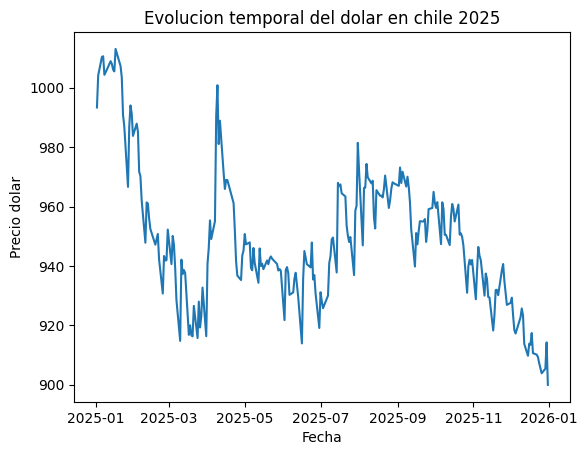

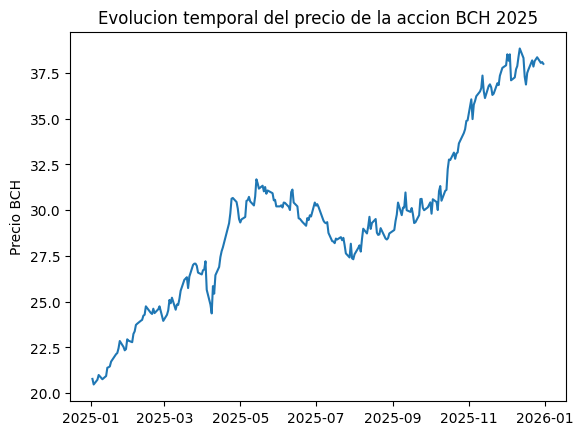

In [67]:
#VISUALIZACIONES
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf

#evoluucion temporal:

plt.plot(df_clean.index, df_clean["CLP=X"], label = "Precio dolar en Chile")
plt.title("Evolucion temporal del dolar en chile 2025")
plt.ylabel("Precio dolar")
plt.xlabel("Fecha")
plt.show()

plt.plot(df_clean.index, df_clean["BCH"], label = "Precio BCH")
plt.title("Evolucion temporal del precio de la accion BCH 2025")
plt.ylabel("Precio BCH")
plt.show()

#PARA EL PRECIO DEL DOLAR: SE OBSERA VARIABILIDAD, PERO TENDENCIA A LA BAJA, PERO EN BCH, SE OBSERVA MAS ESTABILIDAD, PERO TENDENCIA LA ALTA



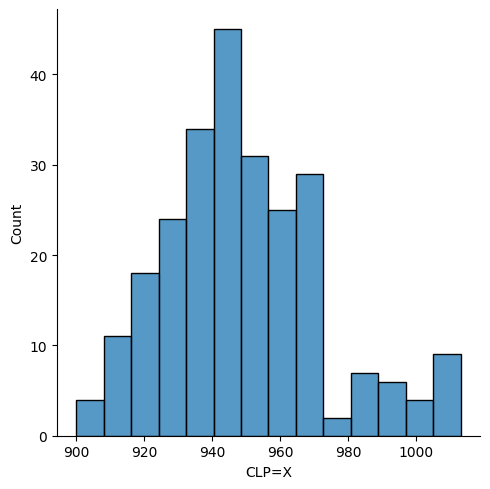

In [74]:
#Distribucion del precio del dolar(CLP=X)
import seaborn as sns
sns.displot(df_clean["CLP=X"], kind = "hist")


<Axes: >

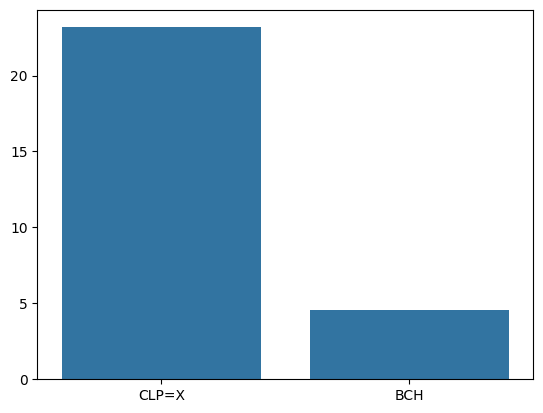

In [73]:
#COMPARACION: desviacion estandar entre variables. Se observa mayor variabilidad del dolar que de BCH

sns.barplot(x=["CLP=X","BCH"], y=[df_clean["CLP=X"].std(), df_clean["BCH"].std()] )

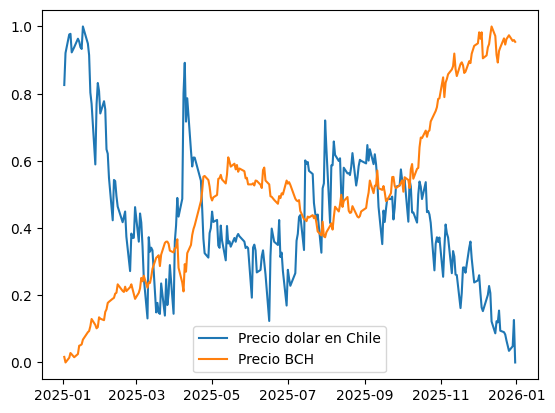

In [75]:
#grafico ambas variables en uno (normalizado):

plt.plot(df_norma.index, df_norma["CLP=X"], label = "Precio dolar en Chile")
plt.plot(df_norma.index, df_norma["BCH"], label = "Precio BCH")
plt.legend()
plt.show()

#SE OBSERVA QUE DURANTE EL AÑO COMPLETO NO SUCEDIO SIEMPRE LO ESPERADO EN LA HIPOSIS INICIAL. PERO SI EN MUCHOS INTERVALOS. SE NOTA LO SIGUIENTE:
#DE ENERO A MARZO DE OBSERA CAIDA EN GENERAL EN EL DOLAR Y SUBIDA EN BCH. SIN EMBARGO, ENTRE ABRIL Y MAYO, AUMENTARON CONJUNTAMENTE, CONTRADICIENDO LA HIPOTESIS, ASI COMMO EN E INTERVALO DE AGOSTO A SEPTIEMBRE, QUE TAMBIEN SE OBSERVA ESO EN ALGUNOS MOMENTOS. LUEGO,ENTRE NOVIEMBRE Y DICIEMBRE, SE VE CLARAMENTE QUE SE CUMPLE QUE EL PRECIO DEL DOLAR BAJA Y LAS ACCIONES DE BCH AUMENTAN. EN OTROS, SE NOTA QUE, CUANDO EL DOLAR AUMENTA, LAS ACCIONES CAEN (JULIO-AGOSTO), CUMPLIENDOSE LA HIPOTESIS, PERO EN EL OTRO SENTIDO.